<a href="https://colab.research.google.com/github/10dimensions/rl-notebooks/blob/main/rl_foundation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ==========================================
# 1. Define the GridWorld Environment
# ==========================================
class GridWorld:
    def __init__(self, grid_size=4):
        self.grid_size = grid_size
        self.n_states = grid_size * grid_size
        self.n_actions = 4  # 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT

        # Terminal state is at the bottom right corner
        self.terminal_state = self.n_states - 1

        # Action mappings (row_change, col_change)
        self.action_effects = {
            0: (-1, 0), # UP
            1: (0, 1),  # RIGHT
            2: (1, 0),  # DOWN
            3: (0, -1)  # LEFT
        }

    def get_transitions(self, state, action):
        """
        Returns a list of tuples: (probability, next_state, reward)
        """
        if state == self.terminal_state:
            return [(1.0, state, 0.0)]

        row, col = divmod(state, self.grid_size)
        d_row, d_col = self.action_effects[action]

        # Clip to grid boundaries (hitting a wall keeps you in the same state)
        next_row = max(0, min(self.grid_size - 1, row + d_row))
        next_col = max(0, min(self.grid_size - 1, col + d_col))

        next_state = next_row * self.grid_size + next_col

        # Reward is -1 for every step
        reward = 0.0 if next_state == self.terminal_state else -1.0

        return [(1.0, next_state, reward)]

In [7]:
# ==========================================
# 2. Implement Policy Iteration
# ==========================================
def policy_iteration(env, gamma=0.9, theta=1e-5):
    """
    Performs Policy Iteration to find the optimal policy and state values.
    """
    n_states = env.n_states
    n_actions = env.n_actions

    # Initialize value function
    V = np.zeros(n_states)

    # FIX 2: Initialize with a RANDOM policy instead of always going RIGHT
    # This prevents the agent from getting permanently stuck on the edges immediately
    policy = np.random.randint(0, n_actions, n_states)

    policy_stable = False

    while not policy_stable:
        # --- STEP 1: Policy Evaluation ---
        while True:
            delta = 0
            for s in range(n_states):
                if s == env.terminal_state:
                    continue

                v = V[s]
                new_v = 0

                a = policy[s]
                transitions = env.get_transitions(s, a)
                for prob, next_s, reward in transitions:
                    new_v += prob * (reward + gamma * V[next_s])

                V[s] = new_v
                delta = max(delta, abs(v - V[s]))

            if delta < theta:
                break

        # --- STEP 2: Policy Improvement ---
        policy_stable = True
        for s in range(n_states):
            if s == env.terminal_state:
                continue

            old_action = policy[s]
            action_values = np.zeros(n_actions)

            for a in range(n_actions):
                transitions = env.get_transitions(s, a)
                for prob, next_s, reward in transitions:
                    action_values[a] += prob * (reward + gamma * V[next_s])

            best_action = np.argmax(action_values)

            if old_action != best_action:
                policy_stable = False
            policy[s] = best_action

    return policy, V

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2317/3664491172.py:28: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title('Optimal Policy $\pi^*(s)$', pad=20, fontsize=14)


Running Policy Iteration...
Done!



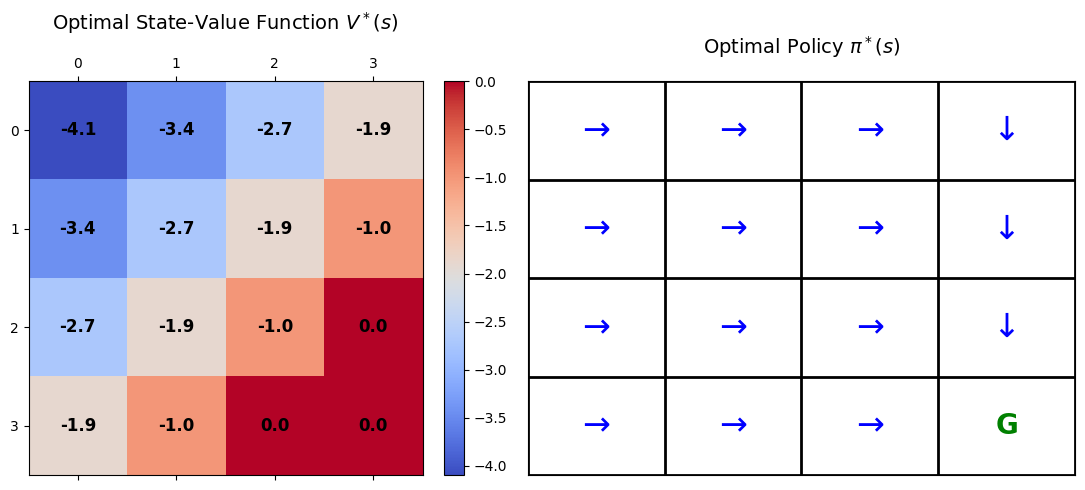

In [8]:
# ==========================================
# 3. Run and Visualize
# ==========================================
if __name__ == "__main__":
    env = GridWorld(grid_size=4)

    print("Running Policy Iteration...")
    # FIX 1: Use gamma = 0.9 to guarantee mathematical convergence
    optimal_policy, optimal_values = policy_iteration(env, gamma=0.9)
    print("Done!\n")

    policy_grid = optimal_policy.reshape(env.grid_size, env.grid_size)
    value_grid = optimal_values.reshape(env.grid_size, env.grid_size)

    arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Optimal State Values
    cax1 = ax1.matshow(value_grid, cmap='coolwarm')
    ax1.set_title('Optimal State-Value Function $V^*(s)$', pad=20, fontsize=14)
    fig.colorbar(cax1, ax=ax1, fraction=0.046, pad=0.04)

    for (i, j), val in np.ndenumerate(value_grid):
        ax1.text(j, i, f'{val:.1f}', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

    # Plot 2: Optimal Policy
    ax2.set_title('Optimal Policy $\pi^*(s)$', pad=20, fontsize=14)
    ax2.set_xticks(np.arange(-.5, env.grid_size, 1), minor=True)
    ax2.set_yticks(np.arange(-.5, env.grid_size, 1), minor=True)
    ax2.grid(which="minor", color="black", linestyle='-', linewidth=2)
    ax2.tick_params(which="minor", bottom=False, left=False)
    ax2.set_xticks([])
    ax2.set_yticks([])

    ax2.invert_yaxis()

    for (i, j), action in np.ndenumerate(policy_grid):
        if i == env.grid_size - 1 and j == env.grid_size - 1:
            ax2.text(j, i, 'G', ha='center', va='center', fontsize=20, color='green', fontweight='bold')
        else:
            ax2.text(j, i, arrows[action], ha='center', va='center', fontsize=24, color='blue')

    plt.tight_layout()
    plt.show()